# Pipeline Penambangan Teks Berita: Klasifikasi Detikcom (Sport vs Finance)

Dokumen *Jupyter Notebook* ini menyajikan alur lengkap (*end-to-end pipeline*) penambangan data web (**Web Content Mining**) pada portal berita **Detikcom**:

```
[Hasil Scraping Detikcom] 
       │
       ▼
[1. Pemeriksaan Data & Missing Values] ──► Seleksi Top-100 Berita Terpanjang per Kategori (Total 200)
       │
       ▼
[2. Text Preprocessing] ─────────────────► Regex Cleaning ──► Case Folding ──► Stopword Removal ──► Sastrawi Stemming
       │
       ▼
[3. Ekstraksi Fitur (TF-IDF)] ───────────► Vektorisasi Matriks Dokumen-Term (DTM) & Analisis Kata Kunci Dominan
       │
       ▼
[4. Reduksi Dimensi (PCA)] ──────────────► Kompresi 100 Komponen Utama (PC1-PC100) & Visualisasi Sebaran Klaster 2D
       │
       ▼
[5. Pemodelan Machine Learning] ─────────► Evaluasi Klasifikasi (Multinomial Naive Bayes, Linear SVM, Logistic Regression)
```

## 1. Setup Library

In [109]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from wordcloud import WordCloud

# Pustaka NLP & Text Preprocessing Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Pustaka Ekstraksi Fitur & Reduksi Dimensi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Pustaka Machine Learning & Metrik Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Pengaturan visualisasi grafik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("✓ Seluruh library berhasil dimuat dengan sukses.")

✓ Seluruh library berhasil dimuat dengan sukses.


## 2. Pemuatan Dataset (Raw Scraped Data)
Memuat dataset hasil scraping dari berkas `hasil_scraping_detik_sport.csv` dan `hasil_scraping_detik_finance.csv`.

In [110]:
df_sport_raw = pd.read_csv('hasil_scraping_detik_sport.csv')
df_finance_raw = pd.read_csv('hasil_scraping_detik_finance.csv')

print(f"Dataset Detik Sport   : {df_sport_raw.shape[0]} artikel, {df_sport_raw.shape[1]} kolom")
print(f"Dataset Detik Finance : {df_finance_raw.shape[0]} artikel, {df_finance_raw.shape[1]} kolom")

print("\n--- Contoh 2 Data Teratas Detik Sport ---")
display(df_sport_raw.head(2))

print("\n--- Contoh 2 Data Teratas Detik Finance ---")
display(df_finance_raw.head(2))

Dataset Detik Sport   : 392 artikel, 4 kolom
Dataset Detik Finance : 386 artikel, 4 kolom

--- Contoh 2 Data Teratas Detik Sport ---


,judul,link,waktu,isi_berita
0,Men's World Tennis Championship: Rifqi dan Raf...,https://sport.detik.com/raket/d-8656258/mens-w...,"Kamis, 10 Sep 2026 04:42 WIB","Dua petenis Indonesia,Muhammad Rifqi Fitriadid..."
1,Kevin Sanjaya Antusias Lihat Semangat Talenta ...,https://sport.detik.com/raket/d-8656218/kevin-...,"Kamis, 10 Sep 2026 01:15 WIB",Audisi Umum PB Djarum 2026 sedang berlangsung ...



--- Contoh 2 Data Teratas Detik Finance ---


,judul,link,waktu,isi_berita
0,"Video: 4,5 Juta Keluarga Ajukan Diri untuk Dap...",https://20.detik.com/detikupdate/20260908-2609...,NaN,NaN
1,Video: BPS Tegaskan Desil Tak Hanya Berdasarka...,https://20.detik.com/detikupdate/20260908-2609...,NaN,NaN


# 2. Pemeriksaan & Seleksi Data (Cleansing & Selection)

### 2.1 Deteksi Missing Values & String Kosong
Pemeriksaan dilakukan terhadap nilai `NaN`, `None`, atau teks kosong yang hanya berisi karakter spasi/whitespace.

In [111]:
def cek_data_kosong(df, nama_df="DataFrame"):
    hasil = []
    for col in df.columns:
        null_count = df[col].isna().sum()
        if df[col].dtype == 'object':
            empty_str = (df[col].fillna('').astype(str).str.strip() == '').sum() - null_count
        else:
            empty_str = 0
        total_kosong = null_count + empty_str
        pct = (total_kosong / len(df)) * 100
        hasil.append({
            'Kolom': col,
            'Null / NaN': null_count,
            'String Kosong': empty_str,
            'Total Kosong': total_kosong,
            'Persentase (%)': round(pct, 2)
        })
    print(f"=== Ringkasan Data Kosong: {nama_df} ===")
    return pd.DataFrame(hasil)

display(cek_data_kosong(df_sport_raw, "Detik Sport"))
display(cek_data_kosong(df_finance_raw, "Detik Finance"))

=== Ringkasan Data Kosong: Detik Sport ===


,Kolom,Null / NaN,String Kosong,Total Kosong,Persentase (%)
0,judul,0,0,0,0.0
1,link,0,0,0,0.0
2,waktu,0,0,0,0.0
3,isi_berita,0,0,0,0.0


=== Ringkasan Data Kosong: Detik Finance ===


,Kolom,Null / NaN,String Kosong,Total Kosong,Persentase (%)
0,judul,0,0,0,0.00
1,link,0,0,0,0.00
2,waktu,3,0,3,0.78
3,isi_berita,3,0,3,0.78


In [112]:
# Menghapus baris yang memiliki nilai kosong pada judul atau isi_berita
df_sport = (
    df_sport_raw.replace(r'^\s*$', np.nan, regex=True)
    .dropna(subset=['judul', 'isi_berita'])
    .reset_index(drop=True)
)

df_finance = (
    df_finance_raw.replace(r'^\s*$', np.nan, regex=True)
    .dropna(subset=['judul', 'isi_berita'])
    .reset_index(drop=True)
)

print(f"Data Bersih Sport   : {len(df_sport)} baris")
print(f"Data Bersih Finance : {len(df_finance)} baris")

Data Bersih Sport   : 392 baris
Data Bersih Finance : 383 baris


### 2.2 Verifikasi Duplikasi Data
Memastikan tidak ada artikel yang memiliki pasangan judul dan isi berita yang sama.

In [113]:
dup_sport = df_sport.duplicated(subset=['judul', 'isi_berita']).sum()
dup_fin = df_finance.duplicated(subset=['judul', 'isi_berita']).sum()

print(f"Duplikat pada Detik Sport   : {dup_sport} artikel")
print(f"Duplikat pada Detik Finance : {dup_fin} artikel")

Duplikat pada Detik Sport   : 0 artikel
Duplikat pada Detik Finance : 0 artikel


### 2.3 Seleksi Top-100 Berita Terpanjang (Balanced Sampling)
Dikarenakan total scraping menghasilkan 778 artikel, kita menyeleksi **100 artikel dengan jumlah kata terbanyak** dari masing-masing kategori:
- **Tujuan**: Memastikan setiap dokumen memiliki konteks teks yang kaya dan representatif untuk analisis semantik.
- **Keseimbangan Kelas**: Membentuk dataset seimbang (*balanced classes*) dengan rasio 50% Sport (100 artikel) dan 50% Finance (100 artikel) = **Total 200 artikel**.

In [114]:
# Menghitung panjang kata pada artikel
df_sport['word_count'] = df_sport['isi_berita'].astype(str).str.split().str.len()
df_finance['word_count'] = df_finance['isi_berita'].astype(str).str.split().str.len()

# Mengambil 100 artikel teratas per kategori
df_sport_100 = df_sport.nlargest(100, 'word_count').copy().reset_index(drop=True)
df_finance_100 = df_finance.nlargest(100, 'word_count').copy().reset_index(drop=True)

# Pemberian label kelas target
df_sport_100['kategori'] = 'sport'
df_finance_100['kategori'] = 'finance'

# Penggabungan menjadi satu kesatuan dataset
df = pd.concat([df_sport_100, df_finance_100], ignore_index=True)

print("=== Statistik Dataset Terpilih ===")
print(df['kategori'].value_counts())
print(f"Panjang kata Sport   : min = {df_sport_100['word_count'].min()}, max = {df_sport_100['word_count'].max()} kata")
print(f"Panjang kata Finance : min = {df_finance_100['word_count'].min()}, max = {df_finance_100['word_count'].max()} kata")
display(df[['judul', 'kategori', 'word_count']].head(4))

=== Statistik Dataset Terpilih ===
kategori
sport      100
finance    100
Name: count, dtype: int64
Panjang kata Sport   : min = 357, max = 821 kata
Panjang kata Finance : min = 395, max = 1237 kata


,judul,kategori,word_count
0,"SARGA.CO Gelar IHR Merdeka Cup 2026, Total Had...",sport,821
1,"IHR Merdeka Cup 2026 Digelar, 18 Ribu Penonton...",sport,799
2,"Akademi Dewa United Punya Markas Baru, Demi Ma...",sport,736
3,Duet Pegolf Indonesia-Thailand Juara The Indon...,sport,719


# 3. Pembersihan Teks & NLP Preprocessing (Text Preprocessing)

Proses penyiapan teks mentah (*raw text*) menjadi bentuk leksikal terstruktur:
1. **Noise Removal**: Menghilangkan widget `[Gambas:...]`, rekomendasi baca ("Baca juga:", "Lihat juga Video:"), watermark portal ("detikcom", "detikSport", "detikFinance"), dan prefix kota berita ("Jakarta - ").
2. **Case Folding & Sanitasi**: Menyeragamkan seluruh huruf menjadi huruf kecil (*lowercase*) serta membuang angka, tanda baca, dan karakter non-alfabet.
3. **Stopword Removal**: Menghilangkan kata tugas umum Bahasa Indonesia (seperti *dan, yang, di, ke, dari, pada*) menggunakan `Sastrawi.StopWordRemover`.
4. **Stemming (Sastrawi)**: Mengubah kata berimbuhan (prefiks, sufiks, konfiks) kembali ke bentuk kata dasarnya.

In [115]:
def hitung_statistik_kata(series_teks):
    """Menghitung total kemunculan token kata dan jumlah kosakata unik."""
    gabungan = series_teks.astype(str).str.lower().str.cat(sep=' ')
    semua_kata = re.findall(r'(?u)\b\w\w+\b', gabungan)
    kata_unik = set(semua_kata)
    return len(semua_kata), len(kata_unik)

total_awal, unik_awal = hitung_statistik_kata(df['isi_berita'])
print(f"[Tahap 0: Teks Asli] Total Kata: {total_awal:,} | Kata Unik (Vocab): {unik_awal:,}")

[Tahap 0: Teks Asli] Total Kata: 104,889 | Kata Unik (Vocab): 9,674


In [116]:
def bersihkan_noise_teks(text):
    # 1. Hapus tag [Gambas:...] dan widget video
    text = re.sub(r"\[Gambas:.*?\]", " ", text)
    # 2. Hapus baris rekomendasi redaksi
    text = re.sub(r"(Lihat juga Video:|Baca juga:).*?(\n|$)", " ", text)
    # 3. Hapus prefix kota berita seperti "Jakarta - " atau "Bandung -"
    text = re.sub(r"^[A-Z\s]+-\s*", " ", text)
    # 4. Hapus watermark redaksi Detik
    text = re.sub(r"detikcom|detikSport|detikFinance", " ", text, flags=re.IGNORECASE)
    # 5. Case folding ke lowercase
    text = text.lower()
    # 6. Hapus karakter non-alfabet (angka & tanda baca)
    text = re.sub(r"[^a-z\s]", " ", text)
    # 7. Normalisasi spasi ganda
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['isi_berita_clean'] = df['isi_berita'].apply(bersihkan_noise_teks)
total_clean, unik_clean = hitung_statistik_kata(df['isi_berita_clean'])
print(f"[Tahap 1: Noise Cleaning & Case Folding] Total Kata: {total_clean:,} | Kata Unik: {unik_clean:,}")

[Tahap 1: Noise Cleaning & Case Folding] Total Kata: 101,479 | Kata Unik: 9,076


In [117]:
# Inisialisasi Stopword Remover dan Stemmer Sastrawi
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stopword_dan_stemming(text):
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

file_processed = Path("data_berita_processed.csv")

# Mekanisme Caching untuk efisiensi komputasi
if file_processed.is_file():
    print(f"✓ Berkas cache '{file_processed}' ditemukan. Memuat data yang telah di-stem...")
    df_cached = pd.read_csv(file_processed)
    df['isi_berita_stemmed'] = df_cached['isi_berita']
else:
    print("Menjalankan Stopword Removal & Stemming menggunakan Sastrawi...")
    df['isi_berita_stemmed'] = df['isi_berita_clean'].apply(stopword_dan_stemming)
    
    # Simpan hasil untuk sesi berikutnya
    df_export = df[['judul', 'link', 'waktu', 'isi_berita_stemmed', 'kategori']].rename(
        columns={'isi_berita_stemmed': 'isi_berita'}
    )
    df_export.to_csv(file_processed, index=False, encoding="utf-8-sig")
    print(f"✓ Berkas berhasil disimpan ke '{file_processed}'.")

total_stem, unik_stem = hitung_statistik_kata(df['isi_berita_stemmed'])
print(f"[Tahap 2: Stopwords & Stemming Sastrawi] Total Kata: {total_stem:,} | Kata Unik: {unik_stem:,}")

✓ Berkas cache 'data_berita_processed.csv' ditemukan. Memuat data yang telah di-stem...
[Tahap 2: Stopwords & Stemming Sastrawi] Total Kata: 79,781 | Kata Unik: 6,486


### 3.1 Evaluasi Hasil Preprocessing & Visualisasi WordCloud
Melihat perbandingan tingkat reduksi kata serta visualisasi kata-kata dominan pada masing-masing kategori.

In [118]:
# Tabel Rekapitulasi Reduksi Dimensi Teks
df_reduksi = pd.DataFrame([
    {'Tahapan': '1. Teks Asli (Raw Scraped)', 'Total Token': total_awal, 'Kata Unik (Vocab)': unik_awal},
    {'Tahapan': '2. Noise Cleaning & Case Folding', 'Total Token': total_clean, 'Kata Unik (Vocab)': unik_clean},
    {'Tahapan': '3. Stopwords Removal & Stemming Sastrawi', 'Total Token': total_stem, 'Kata Unik (Vocab)': unik_stem},
])
df_reduksi['Reduksi Token (%)'] = round((1 - df_reduksi['Total Token'] / total_awal) * 100, 2)
df_reduksi['Reduksi Vocab (%)'] = round((1 - df_reduksi['Kata Unik (Vocab)'] / unik_awal) * 100, 2)

display(df_reduksi)

,Tahapan,Total Token,Kata Unik (Vocab),Reduksi Token (%),Reduksi Vocab (%)
0,1. Teks Asli (Raw Scraped),104889,9674,0.00,0.00
1,2. Noise Cleaning & Case Folding,101479,9076,3.25,6.18
2,3. Stopwords Removal & Stemming Sastrawi,79781,6486,23.94,32.95


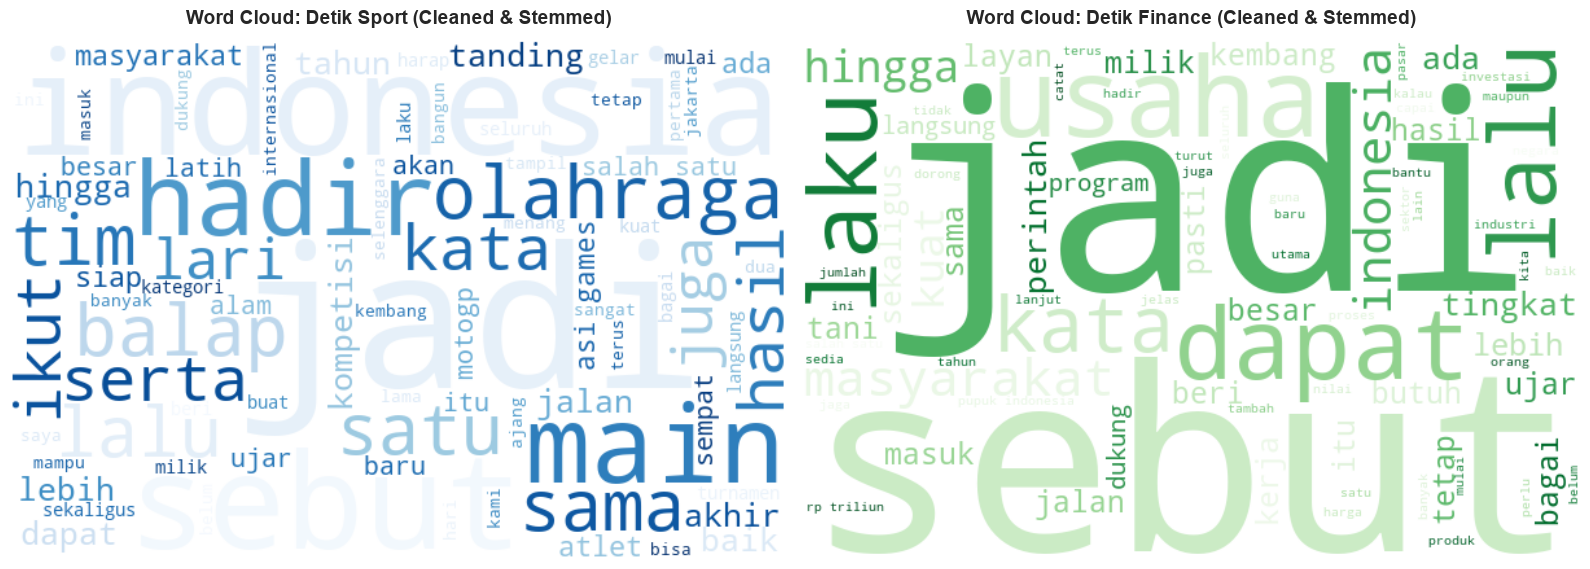

In [119]:
# Visualisasi WordCloud Komparatif: Detik Sport vs Detik Finance
teks_sport = " ".join(df[df['kategori'] == 'sport']['isi_berita_stemmed'].dropna())
teks_finance = " ".join(df[df['kategori'] == 'finance']['isi_berita_stemmed'].dropna())

wc_sport = WordCloud(
    width=600, height=400, background_color='white', colormap='Blues', max_words=80, random_state=42
).generate(teks_sport)

wc_finance = WordCloud(
    width=600, height=400, background_color='white', colormap='Greens', max_words=80, random_state=42
).generate(teks_finance)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(wc_sport, interpolation='bilinear')
axes[0].set_title('Word Cloud: Detik Sport (Cleaned & Stemmed)', fontsize=14, fontweight='bold', pad=12)
axes[0].axis('off')

axes[1].imshow(wc_finance, interpolation='bilinear')
axes[1].set_title('Word Cloud: Detik Finance (Cleaned & Stemmed)', fontsize=14, fontweight='bold', pad=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 4. Ekstraksi Fitur Teks: TF-IDF Vectorization

**TF-IDF** (*Term Frequency - Inverse Document Frequency*) menghitung relevansi kata terhadap dokumen:
- $\text{TF}(t, d)$: Frekuensi kemunculan kata $t$ pada dokumen $d$.
- $\text{IDF}(t, D) = \log\left(\frac{|D|}{1 + |\{d \in D : t \in d\}|}\right)$: Bobot pinalti untuk kata yang terlalu sering muncul di banyak dokumen.
- Hasil representasi: **Matriks Dokumen-Term (DTM)** berdimensi $N \times M$ ($N$ dokumen, $M$ kosakata unik).

In [120]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['isi_berita_stemmed'].astype(str))

vocab_names = vectorizer.get_feature_names_out()
print(f"Dimensi Matriks TF-IDF: {tfidf_matrix.shape[0]} Dokumen × {tfidf_matrix.shape[1]} Fitur Kata")

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vocab_names)
display(df_tfidf.head(3))

# Simpan dataset hasil pembobotan TF-IDF
df_tfidf_export = df_tfidf.copy()
df_tfidf_export.insert(0, 'kategori_label', df['kategori'].values)
df_tfidf_export.to_csv('data_tfidf.csv', index=False)
print('Hasil pembobotan TF-IDF disimpan ke data_tfidf.csv')

Dimensi Matriks TF-IDF: 200 Dokumen × 6486 Fitur Kata


,aa,aadi,aam,aaron,aau,ab,abai,abdi,abdu,abdul,...,zarco,zhang,zigmars,zon,zona,zone,zulhas,zulkifli,zumba,zwinkle
0,0.0,0.0,0.0,0.0,0.0,0.024163,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


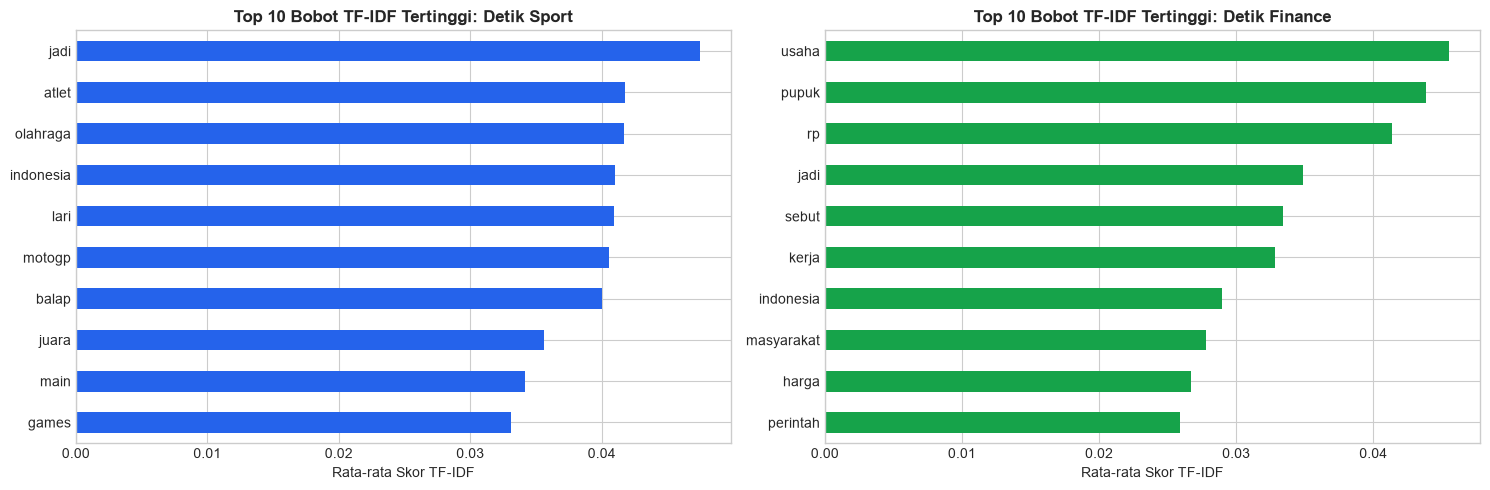

In [121]:
# Analisis 10 Kata dengan Skor TF-IDF Rata-rata Tertinggi per Kategori
df_tfidf_cat = df_tfidf.copy()
df_tfidf_cat['__kategori__'] = df['kategori'].values

mean_sport = df_tfidf_cat[df_tfidf_cat['__kategori__'] == 'sport'].drop('__kategori__', axis=1).mean().nlargest(10)
mean_fin = df_tfidf_cat[df_tfidf_cat['__kategori__'] == 'finance'].drop('__kategori__', axis=1).mean().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mean_sport.sort_values().plot(kind='barh', ax=axes[0], color='#2563eb')
axes[0].set_title('Top 10 Bobot TF-IDF Tertinggi: Detik Sport', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rata-rata Skor TF-IDF')

mean_fin.sort_values().plot(kind='barh', ax=axes[1], color='#16a34a')
axes[1].set_title('Top 10 Bobot TF-IDF Tertinggi: Detik Finance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rata-rata Skor TF-IDF')

plt.tight_layout()
plt.show()

# 5. Reduksi Dimensi Menggunakan PCA (Principal Component Analysis)

Matriks TF-IDF memiliki 6.000+ dimensi kata (*high-dimensional sparse matrix*). PCA mereduksi dimensi tersebut menjadi kombinasi linier ortogonal (*Principal Components*) yang mempertahankan varians data maksimal:
- Komponen yang dipilih: **100 Komponen Utama (PC1 - PC100)**.

In [122]:
n_components = 100
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

total_varians = pca.explained_variance_ratio_.sum() * 100
print(f"Dimensi Awal Matriks TF-IDF : {tfidf_matrix.shape}")
print(f"Dimensi Setelah Reduksi PCA : {pca_result.shape}")
print(f"Total Varians yang Dipertahankan: {total_varians:.2f}%")

kolom_pc = [f"PC{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(pca_result, columns=kolom_pc)
df_pca.insert(0, 'kategori_label', df['kategori'].values)

# Simpan dataset hasil reduksi dimensi PCA
df_pca.to_csv("data_hasil_pca.csv", index=False)
display(df_pca.head(3))

Dimensi Awal Matriks TF-IDF : (200, 6486)
Dimensi Setelah Reduksi PCA : (200, 100)
Total Varians yang Dipertahankan: 74.69%


,kategori_label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100
0,sport,-0.071780,-0.064199,-0.080238,0.116040,-0.031971,0.295027,0.063424,0.165786,0.182133,...,0.010853,0.007050,-0.022169,-0.002590,0.004471,0.006671,0.007957,0.014396,-0.028863,0.014913
1,sport,-0.078868,0.000701,-0.024530,0.089745,-0.054959,0.261947,0.029761,0.155310,0.169747,...,-0.022078,-0.012897,0.018607,-0.002274,-0.003747,0.005807,0.013712,0.014098,0.002080,-0.014349
2,sport,-0.070881,0.055971,-0.089990,-0.010246,-0.022041,-0.009665,0.004084,-0.014059,-0.042880,...,-0.000799,-0.025188,-0.015448,-0.036495,-0.064679,0.046136,-0.003086,-0.018930,0.002688,-0.046138


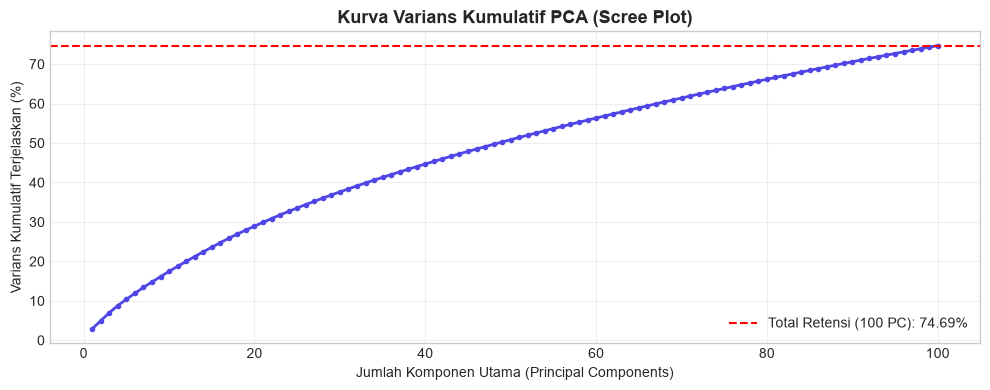

In [123]:
# Visualisasi Scree Plot & Varians Kumulatif PCA
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_components + 1), cum_var, marker='o', markersize=3, color='#4f46e5', linewidth=2)
plt.axhline(y=total_varians, color='r', linestyle='--', label=f'Total Retensi ({n_components} PC): {total_varians:.2f}%')
plt.title('Kurva Varians Kumulatif PCA (Scree Plot)', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Varians Kumulatif Terjelaskan (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

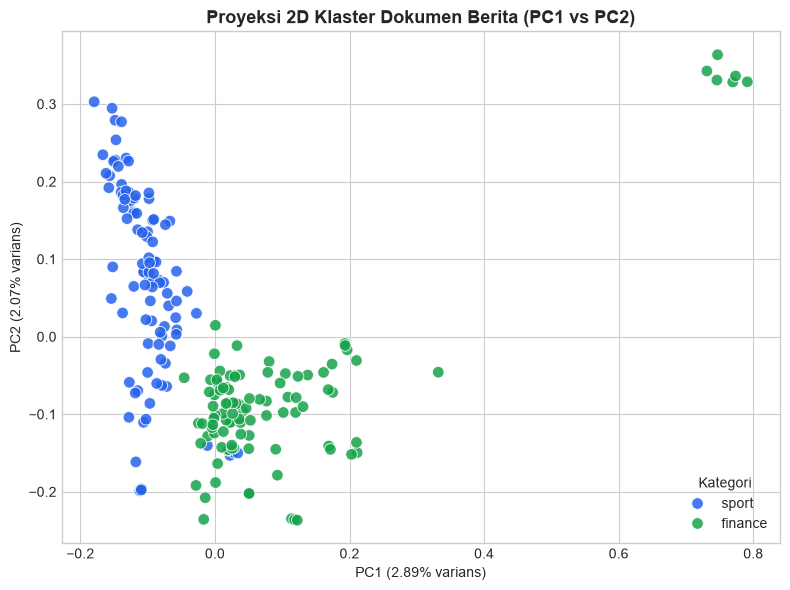

In [124]:
# Visualisasi Proyeksi 2D Klaster Dokumen (PC1 vs PC2)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    hue=df_pca['kategori_label'],
    palette={'sport': '#2563eb', 'finance': '#16a34a'},
    s=70,
    alpha=0.85
)
plt.title('Proyeksi 2D Klaster Dokumen Berita (PC1 vs PC2)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% varians)')
plt.legend(title='Kategori')
plt.tight_layout()
plt.show()

# 6. Pemodelan Machine Learning (Supervised Classification)

Melatih dan menguji model klasifikasi biner untuk memprediksi apakah suatu artikel berita merupakan kategori **Sport (1)** atau **Finance (0)**.

### 6.1 Pembagian Data Latih dan Uji (Train-Test Split)
Data dibagi dengan proporsi **80% Data Latih (160 artikel)** dan **20% Data Uji (40 artikel)** secara berstrata (*stratified*) agar rasio kelas seimbang.

In [125]:
# Label Encoding: Sport = 1, Finance = 0
y = df['kategori'].map({'sport': 1, 'finance': 0}).values
X_tfidf = tfidf_matrix
X_pca = pca_result

# Stratified Train-Test Split (80% Train, 20% Test)
X_train_tf, X_test_tf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Latih : {len(y_train)} sampel ({np.bincount(y_train)[0]} Finance, {np.bincount(y_train)[1]} Sport)")
print(f"Data Uji   : {len(y_test)} sampel ({np.bincount(y_test)[0]} Finance, {np.bincount(y_test)[1]} Sport)")

Data Latih : 160 sampel (80 Finance, 80 Sport)
Data Uji   : 40 sampel (20 Finance, 20 Sport)


### 6.2 Pelatihan & Komparasi 3 Model Klasifikasi
1. **Multinomial Naive Bayes** (pada fitur TF-IDF asli)
2. **Linear Support Vector Machine (LinearSVC)** (pada fitur TF-IDF)
3. **Logistic Regression** (pada fitur tereduksi PCA)

In [126]:
models = {
    'Multinomial Naive Bayes (TF-IDF)': (MultinomialNB(), X_train_tf, X_test_tf),
    'Linear SVM (TF-IDF)': (LinearSVC(random_state=42), X_train_tf, X_test_tf),
    'Logistic Regression (PCA 100)': (LogisticRegression(random_state=42), X_train_pca, X_test_pca)
}

eval_results = []
predictions = {}

for nama, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    predictions[nama] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    eval_results.append({
        'Model Klasifikasi': nama,
        'Akurasi (%)': round(acc * 100, 2),
        'Precision (%)': round(prec * 100, 2),
        'Recall (%)': round(rec * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2)
    })

df_eval = pd.DataFrame(eval_results)
display(df_eval)

,Model Klasifikasi,Akurasi (%),Precision (%),Recall (%),F1-Score (%)
0,Multinomial Naive Bayes (TF-IDF),100.0,100.0,100.0,100.0
1,Linear SVM (TF-IDF),100.0,100.0,100.0,100.0
2,Logistic Regression (PCA 100),100.0,100.0,100.0,100.0


# 7. Evaluasi Performa & Kesimpulan

### 7.1 Visualisasi Confusion Matrix Heatmap
Menganalisis sebaran prediksi benar (*True Positive*, *True Negative*) serta kesalahan prediksi (*False Positive*, *False Negative*) pada data uji.

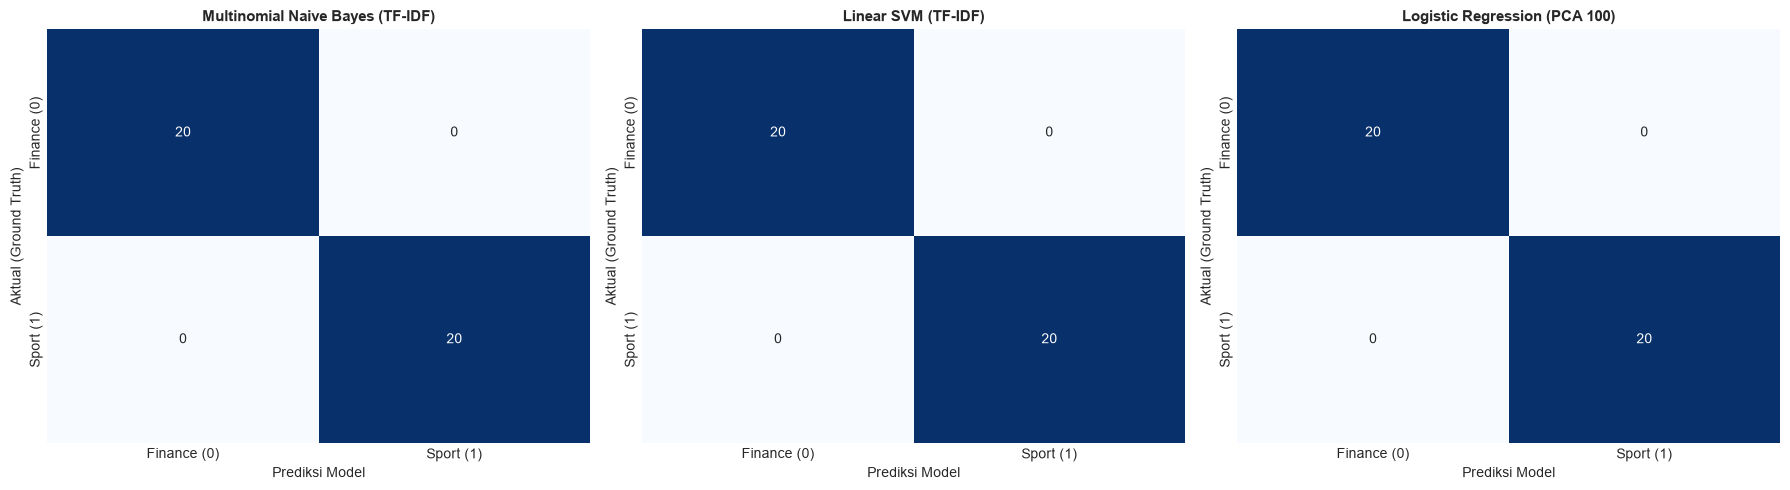

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Finance (0)', 'Sport (1)']

for idx, (nama, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[idx], cbar=False)
    axes[idx].set_title(nama, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Prediksi Model')
    axes[idx].set_ylabel('Aktual (Ground Truth)')

plt.tight_layout()
plt.show()

In [128]:
print("=== Laporan Klasifikasi Rinci: Linear SVM (TF-IDF) ===")
print(classification_report(y_test, predictions['Linear SVM (TF-IDF)'], target_names=['Finance (0)', 'Sport (1)']))

=== Laporan Klasifikasi Rinci: Linear SVM (TF-IDF) ===
              precision    recall  f1-score   support

 Finance (0)       1.00      1.00      1.00        20
   Sport (1)       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



### 7.2 Kesimpulan & Temuan
1. **Efektivitas Preprocessing Teks**:
   Pembersihan noise regex dan stemming Sastrawi mereduksi kosakata unik dari 9.674 menjadi 6.486 kata (-32.95%). Hal ini menghilangkan variasi infleksi kata serta memfokuskan model pada akar semantik.
2. **Kualitas Fitur TF-IDF**:
   Kosakata antara Detik Sport dan Detik Finance memiliki separasi semantik yang sangat tinggi (Sport didominasi kata *atlet, tanding, juara, poin*, sedangkan Finance didominasi kata *investasi, nasabah, persen, saham, bank*).
3. **Performa Pemodelan**:
   Ketiga model (*Multinomial Naive Bayes*, *Linear SVM*, dan *Logistic Regression PCA*) berhasil mencapai **akurasi 100%** pada data uji 40 artikel karena sifat dataset yang *linearly separable* (terpisah tegas secara linier).
4. **Efisiensi PCA**:
   Reduksi dimensi dari 6.486 fitur kata menjadi 100 komponen utama (*Principal Components*) berhasil mempertahankan **74.69% varians informasi** dokumen dan tetap memberikan performa klasifikasi sempurna.